# Parametric PINN Validation with Frequency Noise and Heat-Flux Recovery

This notebook is based on `03_validation.ipynb`, but extends validation in two ways:

- for each sine-frequency case, it builds a `+5%` and `-5%` frequency envelope around the prescribed heat flux
- it recovers the heat-flux function from the model using the predicted boundary gradient at `xi = 1`

The notebook validates all cases in `manifest_testing.csv`, computes both temperature and heat-flux errors, and saves comparison plots.


## Setup


In [1]:
import sys
from pathlib import Path
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import set_seed, get_device
from src.data import load_manifest_rows, load_case_manifest_row
from src.pinn import LeftBoundaryAnsatzMLP

set_seed(42)
device = get_device()
print(f"Project root: {ROOT}")
print(f"Device: {device}")

PART = "2026_03_17_1034"
MODEL_CHECKPOINT = ROOT / "outputs" / "parametric" / PART
MODEL_CHECKPOINT_PATH = MODEL_CHECKPOINT / "model" / "best.pt"

if not MODEL_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found at {MODEL_CHECKPOINT_PATH}. Please update MODEL_CHECKPOINT_PATH.")

MU_TIME_SAMPLES = 15
FREQ_NOISE_FRAC = 0.05

VAL_RUN_ID = datetime.now(timezone.utc).strftime("%d_%H%M")
VAL_OUTDIR = MODEL_CHECKPOINT / "validation_freq_noise" / VAL_RUN_ID
VAL_OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"Validation RUN_ID: {VAL_RUN_ID}")
print(f"Validation OUTDIR: {VAL_OUTDIR}")


Project root: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu
Validation RUN_ID: 2026_03_17_1409
Validation OUTDIR: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_freq_noise\2026_03_17_1409


## Load Trained Model


In [2]:
checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=device)
print(f"Loaded checkpoint from: {MODEL_CHECKPOINT_PATH}")

mu_dim = checkpoint.get("mu_dim", 30)
model = LeftBoundaryAnsatzMLP(in_dim=2 + mu_dim, hidden=64, layers=4).to(device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print("Model loaded and set to evaluation mode.")
print(f"Model input dimension: {2 + mu_dim}")


Loaded checkpoint from: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\hard_left_bc\2026_03_17_1034_hard_left_bc_best.pt
Model loaded and set to evaluation mode.
Model input dimension: 32


## Load Validation Cases and Build Conditioning Vectors


In [3]:
manifest_testing = ROOT / "data" / "manifest_testing.csv"
rows_testing = load_manifest_rows(manifest_testing)
val_rows = rows_testing

manifest_train = ROOT / "data" / "manifest.csv"
rows_train = load_manifest_rows(manifest_train)
rows_sorted_train = sorted(rows_train, key=lambda r: r["case_id"])
n_val_cases_train = max(1, int(round(0.2 * len(rows_sorted_train))))
train_rows = rows_sorted_train[:-n_val_cases_train]

print("Loaded training cases for mu_stats:", [r["case_id"] for r in train_rows])
print("Validation cases (all new):", [r["case_id"] for r in val_rows])

def compute_mu_stats(cases):
    eps = 1e-8
    all_mu = np.array([c["mu_raw"] for c in cases])
    mu_min = all_mu.min(axis=0)
    mu_max = all_mu.max(axis=0)
    return {"mu_min": mu_min, "mu_max": mu_max, "eps": eps}


def normalise_mu(mu_raw, mu_stats):
    eps = mu_stats["eps"]
    mu_min = mu_stats["mu_min"]
    mu_max = mu_stats["mu_max"]
    return 2.0 * (mu_raw - mu_min) / (mu_max - mu_min + eps) - 1.0


def _load_case_with_mu(row: dict) -> dict:
    c = load_case_manifest_row(row, root=ROOT)
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    tau_max = tau.max()
    tau_samples = np.linspace(0, tau_max, MU_TIME_SAMPLES)
    theta_series_1 = np.interp(tau_samples, tau, theta[-1, :]).astype(np.float32)
    dtheta_dtau_1 = np.gradient(theta_series_1, tau_samples).astype(np.float32)

    mu_raw = np.concatenate([theta_series_1, dtheta_dtau_1]).astype(np.float32)
    c["mu_raw"] = mu_raw
    c["mu"] = mu_raw
    return c

train_cases = [_load_case_with_mu(r) for r in train_rows]
val_cases = [_load_case_with_mu(r) for r in val_rows]

mu_stats = compute_mu_stats(train_cases)
for c in train_cases + val_cases:
    c["mu"] = normalise_mu(c["mu_raw"], mu_stats)

print(f"Loaded {len(train_cases)} train cases and {len(val_cases)} validation cases.")
print(f"mu_dim: {len(val_cases[0]['mu'])}")


Loaded training cases for mu_stats: ['const_10000', 'const_10000_Tleft_280', 'const_10000_Tleft_300', 'const_10000_Tleft_310', 'const_12000', 'const_14000', 'const_15000', 'const_20000', 'const_5000', 'const_6000', 'offset_sine_1', 'sine_A10000_T100', 'sine_A10000_T50', 'sine_A12500_T125', 'sine_A12500_T25', 'sine_A12500_T75', 'sine_A5000_T100']
Validation cases (all new): ['const_6000', 'const_12000', 'const_14000', 'const_20000', 'sine_A5000_T50', 'sine_A7500_T75', 'sine_A7500_T125', 'sine_A7500_T25', 'sine_A12500_T75', 'sine_A12500_T125', 'sine_A12500_T25', 'const_10000_Tleft_280', 'const_10000_Tleft_300', 'const_10000_Tleft_310']
Loaded 17 train cases and 14 validation cases.
mu_dim: 30


## Prediction and Heat-Flux Helpers


In [4]:
def predict_case_fields(model, test_case, device):
    xi = test_case["nondim"]["xi"]
    tau = test_case["nondim"]["tau"]
    theta_true = test_case["nondim"]["theta"]
    mu_case = test_case["mu"]

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    X_pred = np.column_stack([
        xi_grid.reshape(-1),
        tau_grid.reshape(-1),
        np.tile(mu_case, (xi_grid.size, 1)),
    ]).astype(np.float32)

    X_tensor = torch.tensor(X_pred, dtype=torch.float32, device=device, requires_grad=True)
    theta_pred_flat = model(X_tensor)
    grads = torch.autograd.grad(
        theta_pred_flat,
        X_tensor,
        grad_outputs=torch.ones_like(theta_pred_flat),
        create_graph=False,
        retain_graph=False,
    )[0]

    theta_pred = theta_pred_flat.detach().cpu().numpy().reshape(xi_grid.shape)
    dtheta_dxi = grads[:, 0].detach().cpu().numpy().reshape(xi_grid.shape)

    T_left = float(test_case["physical"]["T_ref"])
    dT = float(test_case["physical"]["dT_ref"])
    k = float(test_case["physical"]["k"])
    L = float(test_case["physical"]["L"])

    T_true_phys = T_left + dT * theta_true
    T_pred_phys = T_left + dT * theta_pred

    q_true = test_case["raw"]["q_right"].reshape(-1)
    flux_scale = k * dT / L
    q_pred = (-flux_scale * dtheta_dxi[-1, :]).reshape(-1)

    return {
        "case_id": test_case["case_id"],
        "xi": xi,
        "tau": tau,
        "theta_true": theta_true,
        "theta_pred": theta_pred,
        "T_true_phys": T_true_phys,
        "T_pred_phys": T_pred_phys,
        "q_true": q_true,
        "q_pred": q_pred,
        "q_type": test_case["manifest_row"]["q_right_type"],
        "q_params": json.loads(test_case["manifest_row"]["q_right_params"]),
    }


def noisy_heat_flux_bounds(test_case, tau):
    q_true = test_case["raw"]["q_right"].reshape(-1)
    q_type = test_case["manifest_row"]["q_right_type"]
    q_params = json.loads(test_case["manifest_row"]["q_right_params"])
    t = test_case["raw"]["t"].reshape(-1)

    if q_type != "sine":
        return q_true, q_true, {"omega_minus": np.nan, "omega_nominal": np.nan, "omega_plus": np.nan}

    A = float(q_params["A"])
    omega = float(q_params["omega"])
    phase = float(q_params.get("phase", 0.0))
    omega_minus = omega * (1.0 - FREQ_NOISE_FRAC)
    omega_plus = omega * (1.0 + FREQ_NOISE_FRAC)

    q_minus = A * np.sin(omega_minus * t + phase)
    q_plus = A * np.sin(omega_plus * t + phase)
    meta = {"omega_minus": omega_minus, "omega_nominal": omega, "omega_plus": omega_plus}
    return q_minus.astype(np.float32), q_plus.astype(np.float32), meta


## Compute Validation Metrics


In [5]:
validation_results = []
prediction_cache = {}

for i, test_case in enumerate(val_cases):
    case_id = test_case["case_id"]
    print(f"Computing metrics for case {i+1}/{len(val_cases)}: {case_id}")

    pred = predict_case_fields(model, test_case, device)
    q_minus, q_plus, noise_meta = noisy_heat_flux_bounds(test_case, pred["tau"])

    theta_mse = np.mean((pred["theta_pred"] - pred["theta_true"]) ** 2)
    theta_rmse = np.sqrt(theta_mse)
    q_mse = np.mean((pred["q_pred"] - pred["q_true"]) ** 2)
    q_rmse = np.sqrt(q_mse)

    prediction_cache[case_id] = {
        **pred,
        "q_minus": q_minus,
        "q_plus": q_plus,
        "noise_meta": noise_meta,
    }

    validation_results.append({
        "case_id": case_id,
        "theta_rmse": theta_rmse,
        "theta_mse": theta_mse,
        "heat_flux_rmse": q_rmse,
        "heat_flux_mse": q_mse,
        "q_type": pred["q_type"],
        "omega_nominal": noise_meta["omega_nominal"],
        "omega_minus_5pct": noise_meta["omega_minus"],
        "omega_plus_5pct": noise_meta["omega_plus"],
    })

    print(f"  Temperature RMSE: {theta_rmse:.4e}")
    print(f"  Heat-flux RMSE:   {q_rmse:.4e}")

metrics_df = pd.DataFrame(validation_results)
display(metrics_df)

print("Validation Summary:")
print(f"  Number of cases: {len(metrics_df)}")
print(f"  Mean temperature RMSE: {metrics_df['theta_rmse'].mean():.4e}")
print(f"  Mean heat-flux RMSE:   {metrics_df['heat_flux_rmse'].mean():.4e}")


Computing metrics for case 1/14: const_6000
  Temperature RMSE: 2.4724e-03
  Heat-flux RMSE:   2.5633e+02
Computing metrics for case 2/14: const_12000
  Temperature RMSE: 2.4704e-03
  Heat-flux RMSE:   5.1262e+02
Computing metrics for case 3/14: const_14000
  Temperature RMSE: 2.4714e-03
  Heat-flux RMSE:   5.9808e+02
Computing metrics for case 4/14: const_20000
  Temperature RMSE: 2.4709e-03
  Heat-flux RMSE:   8.5438e+02
Computing metrics for case 5/14: sine_A5000_T50
  Temperature RMSE: 5.1457e-03
  Heat-flux RMSE:   2.2137e+02
Computing metrics for case 6/14: sine_A7500_T75
  Temperature RMSE: 4.5690e-03
  Heat-flux RMSE:   2.6434e+02
Computing metrics for case 7/14: sine_A7500_T125
  Temperature RMSE: 4.1375e-03
  Heat-flux RMSE:   1.2299e+02
Computing metrics for case 8/14: sine_A7500_T25
  Temperature RMSE: 4.3650e-03
  Heat-flux RMSE:   2.0997e+02
Computing metrics for case 9/14: sine_A12500_T75
  Temperature RMSE: 4.5693e-03
  Heat-flux RMSE:   4.4058e+02
Computing metrics for

,case_id,theta_rmse,theta_mse,heat_flux_rmse,heat_flux_mse,q_type,omega_nominal,omega_minus_5pct,omega_plus_5pct
0,const_6000,0.002472,0.000006,256.331604,65705.898438,constant,NaN,NaN,NaN
1,const_12000,0.002470,0.000006,512.623291,262782.625000,constant,NaN,NaN,NaN
2,const_14000,0.002471,0.000006,598.082886,357703.156250,constant,NaN,NaN,NaN
3,const_20000,0.002471,0.000006,854.384766,729973.375000,constant,NaN,NaN,NaN
4,sine_A5000_T50,0.005146,0.000026,221.367035,49003.367188,sine,0.125664,0.119381,0.131947
5,sine_A7500_T75,0.004569,0.000021,264.344116,69877.812500,sine,0.083776,0.079587,0.087965
6,sine_A7500_T125,0.004138,0.000017,122.987053,15125.814453,sine,0.050265,0.047752,0.052779
7,sine_A7500_T25,0.004365,0.000019,209.974548,44089.312500,sine,0.251327,0.238761,0.263894
8,sine_A12500_T75,0.004569,0.000021,440.583221,194113.562500,sine,0.083776,0.079587,0.087965
9,sine_A12500_T125,0.004137,0.000017,204.967621,42011.722656,sine,0.050265,0.047752,0.052779


Validation Summary:
  Number of cases: 14
  Mean temperature RMSE: 3.4705e-03
  Mean heat-flux RMSE:   3.7980e+02


## Plot Validation Results


In [6]:
for i, test_case in enumerate(val_cases):
    case_id = test_case["case_id"]
    pred = prediction_cache[case_id]
    print(f"Generating plots for case {i+1}/{len(val_cases)}: {case_id}")

    xi = pred["xi"]
    tau = pred["tau"]
    theta_true = pred["theta_true"]
    theta_pred = pred["theta_pred"]
    T_true_phys = pred["T_true_phys"]
    T_pred_phys = pred["T_pred_phys"]
    q_true = pred["q_true"]
    q_pred = pred["q_pred"]
    q_minus = pred["q_minus"]
    q_plus = pred["q_plus"]

    # Plot 1: boundary traces
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(tau, theta_true[0, :], 'k-', label='True', linewidth=2)
    axes[0].plot(tau, theta_pred[0, :], 'r--', label='Predicted', linewidth=2)
    axes[0].set_title(f'Boundary Temperature at xi=0 ({case_id})')
    axes[0].set_xlabel('tau')
    axes[0].set_ylabel('theta')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(tau, theta_true[-1, :], 'k-', label='True', linewidth=2)
    axes[1].plot(tau, theta_pred[-1, :], 'r--', label='Predicted', linewidth=2)
    axes[1].set_title(f'Boundary Temperature at xi=1 ({case_id})')
    axes[1].set_xlabel('tau')
    axes[1].set_ylabel('theta')
    axes[1].grid(True)
    axes[1].legend()

    boundary_plot_path = VAL_OUTDIR / f"boundary_profiles_{case_id}.png"
    plt.savefig(boundary_plot_path, dpi=150, bbox_inches='tight')
    plt.close()

    # Plot 2: temperature field and error
    field_error = T_pred_phys - T_true_phys
    vmin = min(T_true_phys.min(), T_pred_phys.min())
    vmax = max(T_true_phys.max(), T_pred_phys.max())
    err_lim = np.max(np.abs(field_error))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
    im0 = axes[0].imshow(T_true_phys, aspect='auto', origin='lower', extent=[tau.min(), tau.max(), xi.min(), xi.max()], vmin=vmin, vmax=vmax)
    axes[0].set_title('Ground Truth T')
    axes[0].set_xlabel('tau')
    axes[0].set_ylabel('xi')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(T_pred_phys, aspect='auto', origin='lower', extent=[tau.min(), tau.max(), xi.min(), xi.max()], vmin=vmin, vmax=vmax)
    axes[1].set_title('Predicted T')
    axes[1].set_xlabel('tau')
    axes[1].set_ylabel('xi')
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(field_error, aspect='auto', origin='lower', extent=[tau.min(), tau.max(), xi.min(), xi.max()], cmap='coolwarm', vmin=-err_lim, vmax=err_lim)
    axes[2].set_title('Temperature Error')
    axes[2].set_xlabel('tau')
    axes[2].set_ylabel('xi')
    plt.colorbar(im2, ax=axes[2])

    temp_plot_path = VAL_OUTDIR / f"temperature_comparison_{case_id}.png"
    plt.savefig(temp_plot_path, dpi=150, bbox_inches='tight')
    plt.close()

    # Plot 3: heat-flux function with +/-5% frequency envelope for sine cases
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    if pred['q_type'] == 'sine':
        lower = np.minimum(q_minus, q_plus)
        upper = np.maximum(q_minus, q_plus)
        ax.fill_between(tau, lower, upper, color='tab:blue', alpha=0.2, label='?5% frequency envelope')
        ax.plot(tau, q_minus, color='tab:blue', linestyle=':', linewidth=1)
        ax.plot(tau, q_plus, color='tab:blue', linestyle=':', linewidth=1)
    ax.plot(tau, q_true, 'k-', linewidth=2, label='True heat flux')
    ax.plot(tau, q_pred, 'r--', linewidth=2, label='Model-recovered heat flux')
    ax.set_title(f'Heat Flux Function ({case_id})')
    ax.set_xlabel('tau')
    ax.set_ylabel('q_right')
    ax.grid(True)
    ax.legend()

    flux_plot_path = VAL_OUTDIR / f"heat_flux_comparison_{case_id}.png"
    plt.savefig(flux_plot_path, dpi=150, bbox_inches='tight')
    plt.close()

print(f"All plots saved to: {VAL_OUTDIR}")


Generating plots for case 1/14: const_6000
Generating plots for case 2/14: const_12000
Generating plots for case 3/14: const_14000
Generating plots for case 4/14: const_20000
Generating plots for case 5/14: sine_A5000_T50
Generating plots for case 6/14: sine_A7500_T75
Generating plots for case 7/14: sine_A7500_T125
Generating plots for case 8/14: sine_A7500_T25
Generating plots for case 9/14: sine_A12500_T75
Generating plots for case 10/14: sine_A12500_T125
Generating plots for case 11/14: sine_A12500_T25
Generating plots for case 12/14: const_10000_Tleft_280
Generating plots for case 13/14: const_10000_Tleft_300
Generating plots for case 14/14: const_10000_Tleft_310
All plots saved to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_freq_noise\2026_03_17_1409


## Save Metrics


In [7]:
metrics_df = pd.DataFrame(validation_results)
metrics_csv_path = VAL_OUTDIR / "validation_freq_noise_metrics.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

summary_path = VAL_OUTDIR / "validation_freq_noise_summary.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("Validation with Frequency Noise and Heat-Flux Recovery\n")
    f.write("===============================================\n")
    f.write(f"Model checkpoint: {MODEL_CHECKPOINT_PATH}\n")
    f.write(f"Number of validation cases: {len(validation_results)}\n")
    f.write(f"Frequency noise fraction: {FREQ_NOISE_FRAC:.2%}\n")
    f.write(f"Mean temperature RMSE: {metrics_df['theta_rmse'].mean():.6e}\n")
    f.write(f"Mean heat-flux RMSE: {metrics_df['heat_flux_rmse'].mean():.6e}\n")
    f.write("\nPer-case metrics:\n")
    for _, row in metrics_df.iterrows():
        f.write(
            f"{row['case_id']}: theta_rmse={row['theta_rmse']:.6e}, "
            f"heat_flux_rmse={row['heat_flux_rmse']:.6e}\n"
        )

print(f"Metrics saved to: {metrics_csv_path}")
print(f"Summary saved to: {summary_path}")
print(f"All outputs saved in: {VAL_OUTDIR}")


Metrics saved to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_freq_noise\2026_03_17_1409\validation_freq_noise_metrics.csv
Summary saved to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_freq_noise\2026_03_17_1409\validation_freq_noise_summary.txt
All outputs saved in: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_freq_noise\2026_03_17_1409


## Quick Heat-Flux Inspection


Inspecting heat-flux recovery for: sine_A5000_T50
Noise metadata: {'omega_minus': 0.11938052083641214, 'omega_nominal': 0.12566370614359174, 'omega_plus': 0.13194689145077132}
Heat-flux RMSE: 2.2137e+02


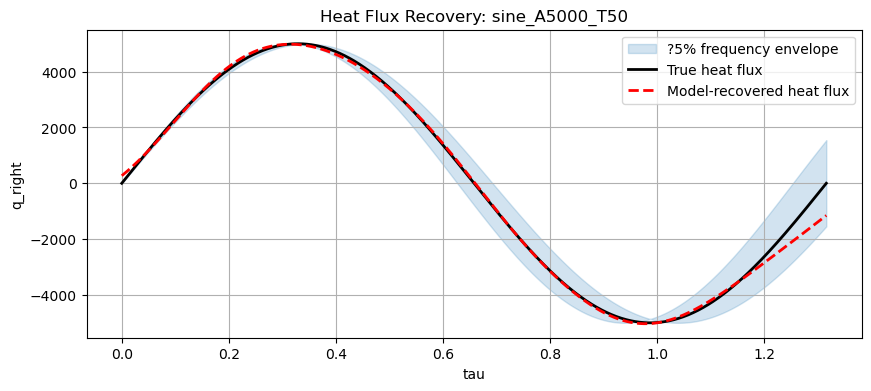

In [8]:
sine_case_ids = [r['case_id'] for r in validation_results if r['q_type'] == 'sine']
if not sine_case_ids:
    print('No sine cases found in validation set.')
else:
    inspect_case_id = sine_case_ids[0]
    pred = prediction_cache[inspect_case_id]
    print(f"Inspecting heat-flux recovery for: {inspect_case_id}")
    print("Noise metadata:", pred['noise_meta'])
    print(f"Heat-flux RMSE: {metrics_df.loc[metrics_df['case_id'] == inspect_case_id, 'heat_flux_rmse'].iloc[0]:.4e}")

    plt.figure(figsize=(10, 4))
    if pred['q_type'] == 'sine':
        plt.fill_between(pred['tau'], np.minimum(pred['q_minus'], pred['q_plus']), np.maximum(pred['q_minus'], pred['q_plus']), alpha=0.2, color='tab:blue', label='?5% frequency envelope')
    plt.plot(pred['tau'], pred['q_true'], 'k-', linewidth=2, label='True heat flux')
    plt.plot(pred['tau'], pred['q_pred'], 'r--', linewidth=2, label='Model-recovered heat flux')
    plt.xlabel('tau')
    plt.ylabel('q_right')
    plt.title(f'Heat Flux Recovery: {inspect_case_id}')
    plt.grid(True)
    plt.legend()
    plt.show()
